# US Visa Prediction Project
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training 
* Choose best model

### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. 
The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## 1) Problem statement.

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

## 2) Data Collection.
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### 2.1 Import Data and Required Packages
**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
#Import the CSV Data as Pandas DataFrame**
df= pd.read_csv("C:/Users/shaya/Desktop/labmentix/mMLOPs-Production-Ready-Machine-Learning-Project/notebook/Visadataset.csv")
                

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
#shape of data
df.shape

(25480, 12)

In [5]:
#summary of dataset
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [6]:
#check dtypes and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [7]:
#3. EXPLORING DATA
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [8]:
type(categorical_features)

list

In [9]:
print(f"we have{len(numeric_features)} numerical features : {numeric_features}")

we have3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [10]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
unit_o

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

## Univariate Analysis
* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are
* **Bivariate Analysis:** The analysis of two variables.
* **Multivariate Analysis:** The analysis of two or more variables.

plotting numeric columns

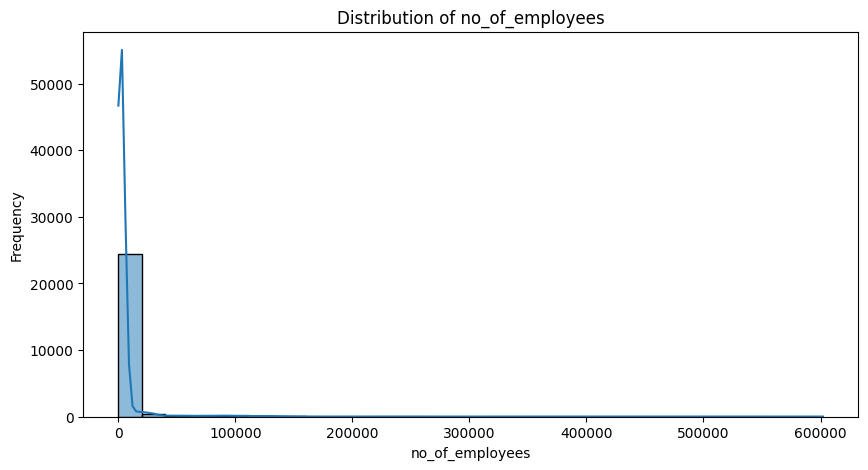

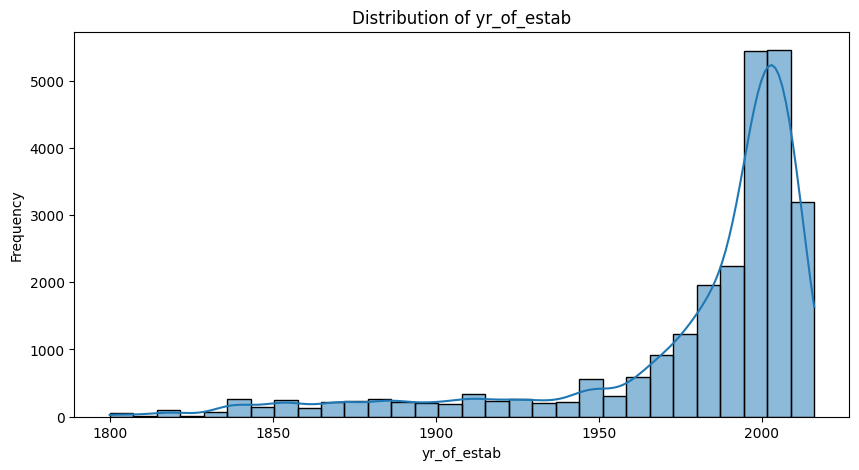

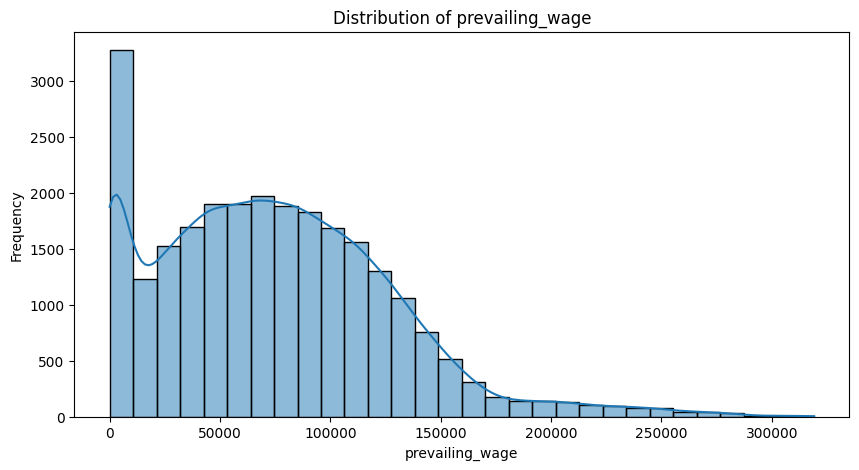

In [11]:
for i in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[i], kde=True, bins=30)
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.show()


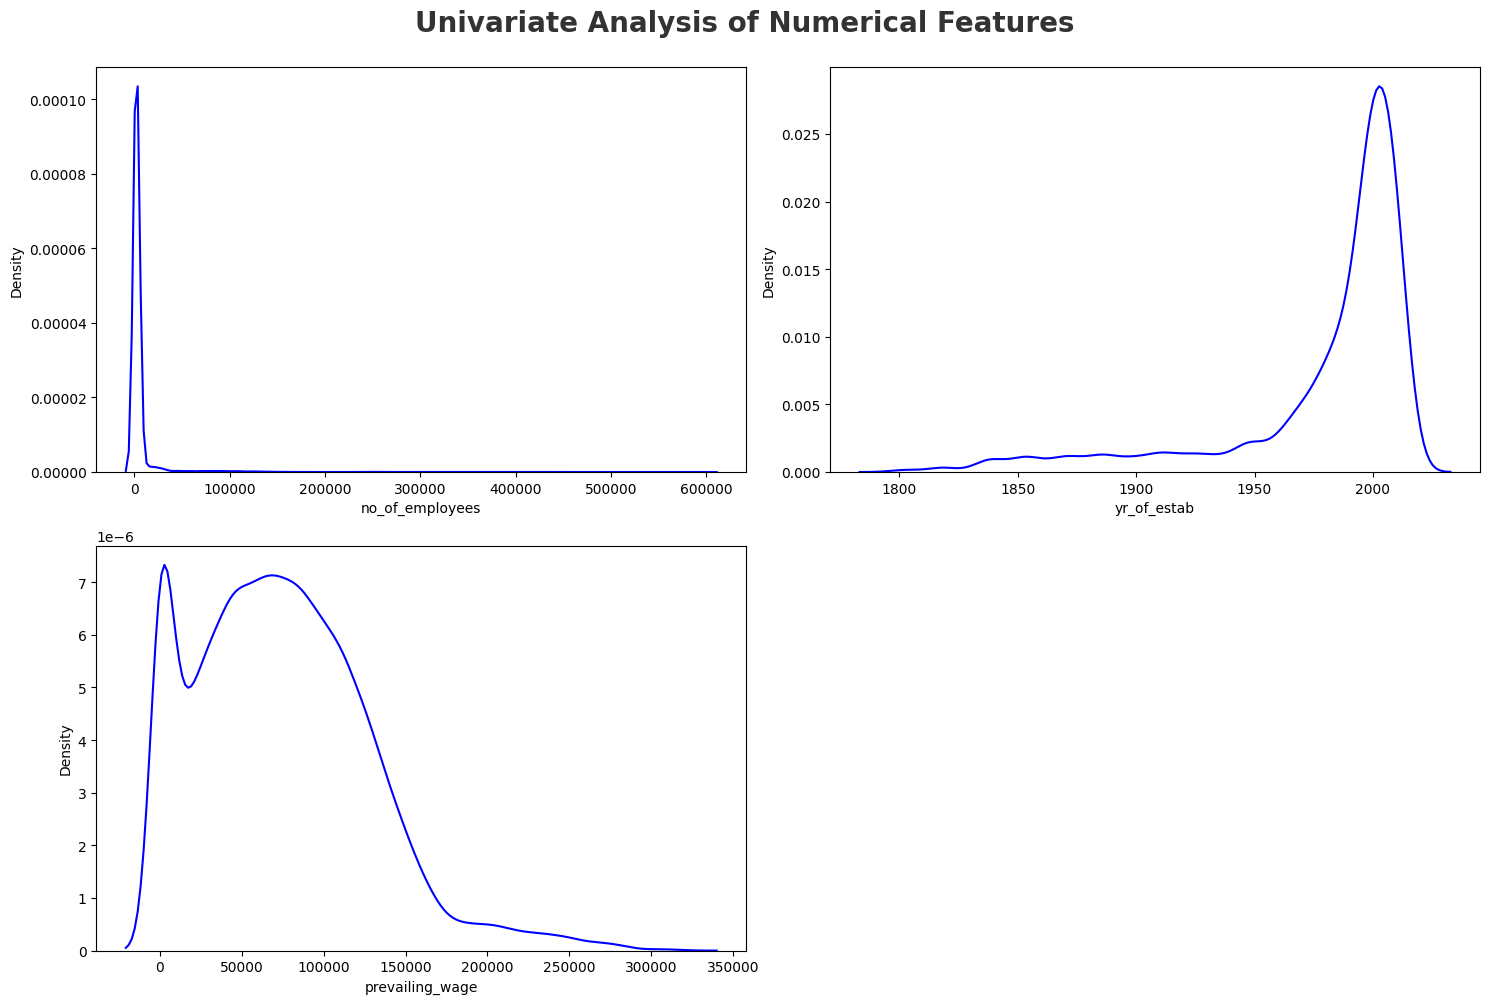

In [12]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    

**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-wage` is a right-skewed distribution.

plotting categorial features

In [13]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [14]:
# categorical columns
categorical_features.remove('case_id')


In [15]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

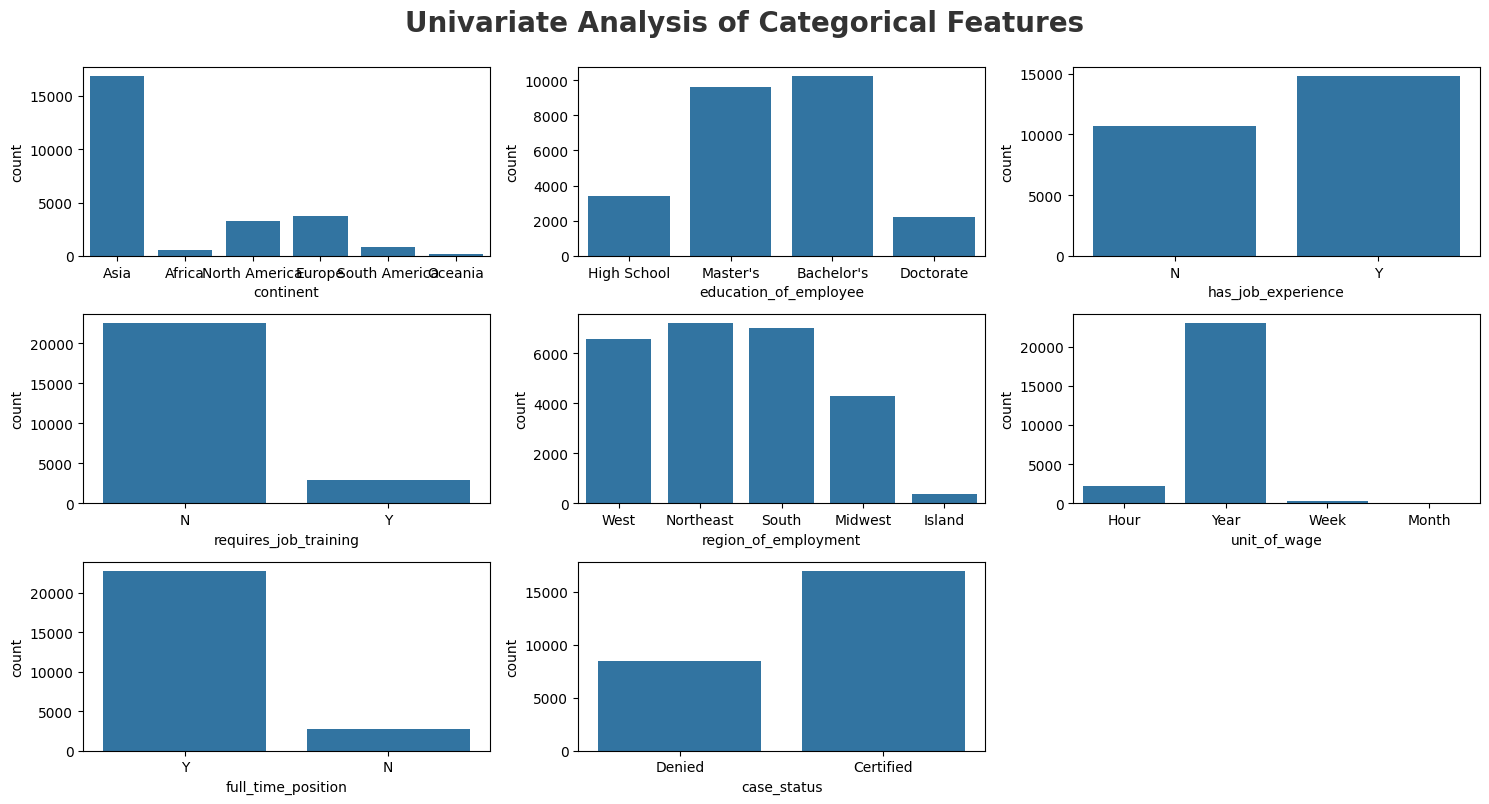

In [16]:
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have signle category dominating.
 - In rest of the columns are balanced.

* Multivariate analysis is the analysis of more than one variable.

In [17]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

In [18]:
print(f"we have {len(discrete_features)} discrete features : {discrete_features}")
print(f"we have {len(continuous_features)} continuous features : {continuous_features}")

we have 0 discrete features : []
we have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


multicollinearity of nemerical features

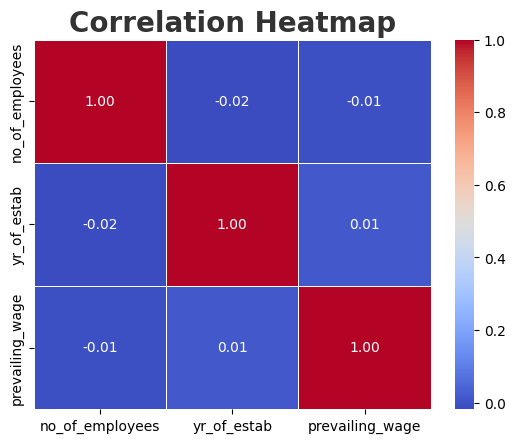

In [19]:
cor = df.corr(numeric_only=True)  # <-- no .all
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=20, fontweight='bold', alpha=0.8)
plt.show()

In [20]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### Check Multicollinearity for Categorical features
* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e case_status**

Null Hypothesis ($ H_0 $): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis ($ H_1 $): The Feature and Target column are not independent (Correalted)

In [21]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


In [22]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2_results = []  # store all results

for feature in categorical_features:
    chi2_statistic, p_value, dof, expected_freq = chi2_contingency(pd.crosstab(df['case_status'], df[feature]))
    
    # hypothesis result based on p-value
    hypothesis_result = 'Reject Null Hypothesis' if p_value < 0.05 else 'Fail to Reject Null Hypothesis'
    
    # store everything in a list
    chi2_results.append([feature, chi2_statistic, p_value, dof, expected_freq, hypothesis_result])

# create DataFrame
result = pd.DataFrame(chi2_results, columns=['Column', 'Chi2 Statistic', 'P-Value', 'DOF', 'Expected Freq', 'Hypothesis Result'])
result

,Column,Chi2 Statistic,P-Value,DOF,Expected Freq,Hypothesis Result
0,continent,351.380408,8.828798e-74,5,"[[368.0109105180534, 11261.401020408162, 2492....",Reject Null Hypothesis
1,education_of_employee,2772.207275,0.000000e+00,3,"[[6835.251648351648, 1464.028885400314, 2284.2...",Reject Null Hypothesis
2,has_job_experience,940.058096,1.922560e-206,1,"[[7131.797645211931, 9886.202354788069], [3546...",Reject Null Hypothesis
3,requires_job_training,1.752484,1.855647e-01,1,"[[15044.36616954474, 1973.633830455259], [7480...",Fail to Reject Null Hypothesis
4,region_of_employment,298.450836,2.338664e-63,4,"[[250.4611459968603, 2876.629748822606, 4805.5...",Reject Null Hypothesis
5,unit_of_wage,1108.507062,5.193385e-240,3,"[[1440.6525117739404, 59.44277864992151, 181.6...",Reject Null Hypothesis
6,full_time_position,4.029932,4.469975e-02,1,"[[1807.9955259026688, 15210.004474097332], [89...",Reject Null Hypothesis
7,case_status,25475.491853,0.000000e+00,1,"[[11366.260753532182, 5651.739246467818], [565...",Reject Null Hypothesis


In [23]:
#null value
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [24]:
continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :',continues_features)

Num of continues features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


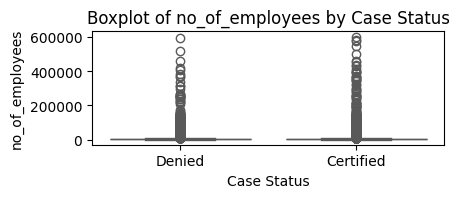

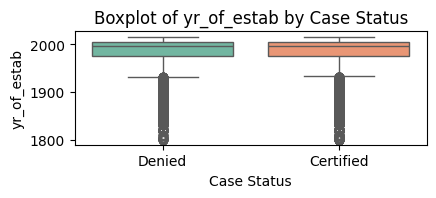

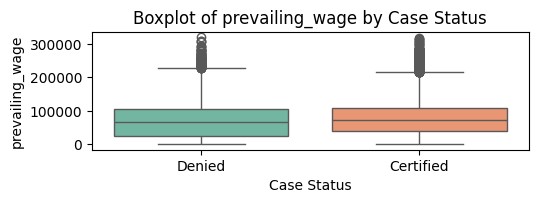

In [25]:

for i in range(len(continues_features)):
    plt.figure(figsize=(10, 5))
    plt.subplot(3,2,i+1)  # 3 rows, 2 columns, ith plot
    sns.boxplot(x='case_status', y=continues_features[i], data=df, palette='Set2')
   
    plt.xlabel('Case Status')
    plt.ylabel(continues_features[i])
    plt.title(f'Boxplot of {continues_features[i]} by Case Status')

plt.tight_layout()
plt.show()

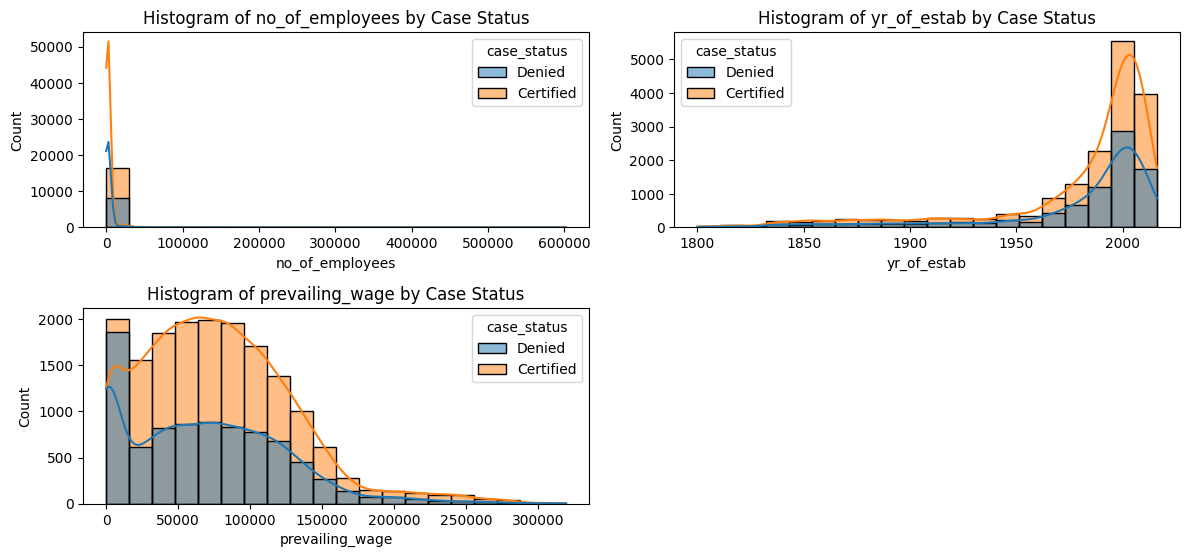

In [26]:


plt.figure(figsize=(12, 8))

for i in range(len(continues_features)):
    plt.subplot(3, 2, i+1)  # 3 rows, 2 columns
    sns.histplot(data=df, x=continues_features[i], hue='case_status', bins=20, kde=True)
    plt.xlabel(continues_features[i])
    plt.ylabel('Count')
    plt.title(f'Histogram of {continues_features[i]} by Case Status')

plt.tight_layout()
plt.show()

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `case_status` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

4)visualise target

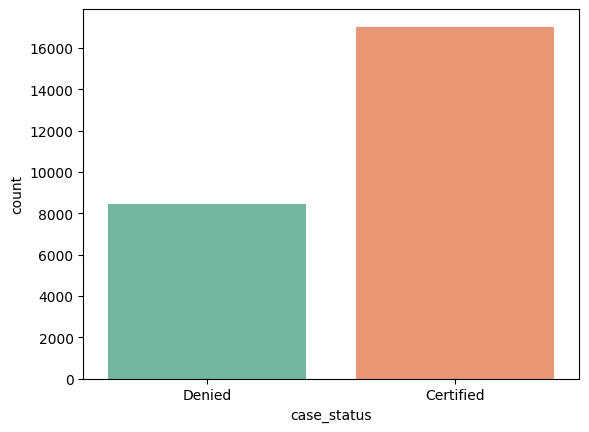

In [27]:
sns.countplot(x='case_status', data=df, palette='Set2')
plt.show()

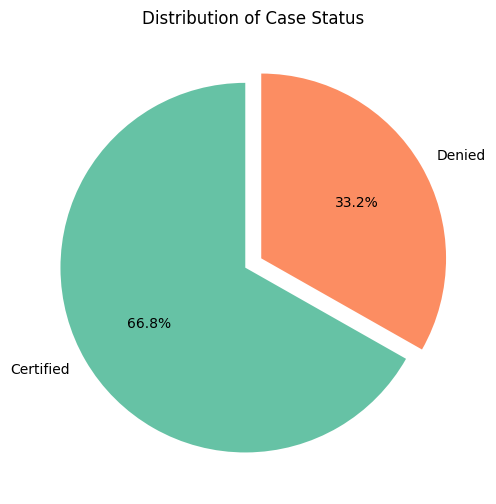

In [28]:
counts = df['case_status'].value_counts()
plt.figure(figsize=(6, 6))
df['case_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]* len(counts), 
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Case Status')
plt.ylabel('')
plt.show()

* From the chart it is seen that the Target Variable is Imbalanced
**What is imbalanced data?**

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

### 4.2 Does applicant Continent has any impact on Visa status ?

In [29]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

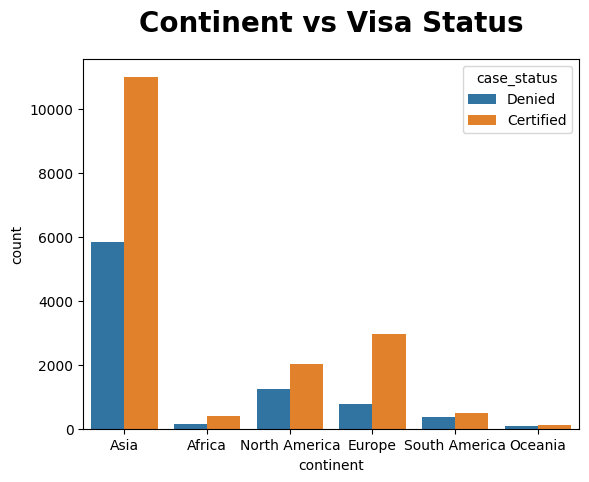

In [30]:
sns.countplot(x='continent',data=df,hue='case_status')
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.show()

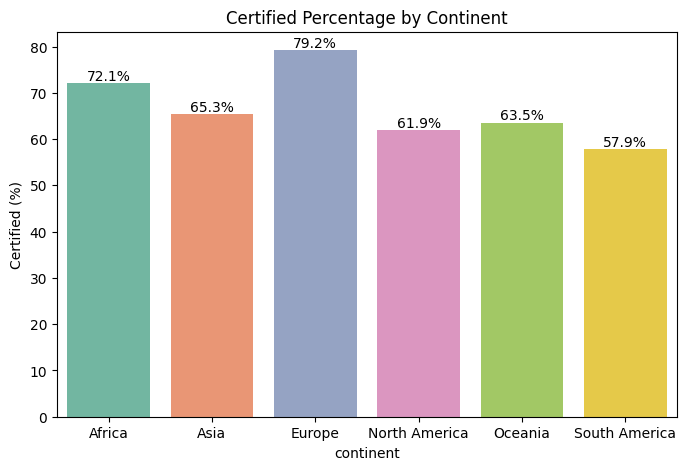

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('continent')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='continent',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by Continent')
plt.show()

**Report:**
* As per the first chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

### 4.3 Does applicant education has any impact on Visa status ?

In [32]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

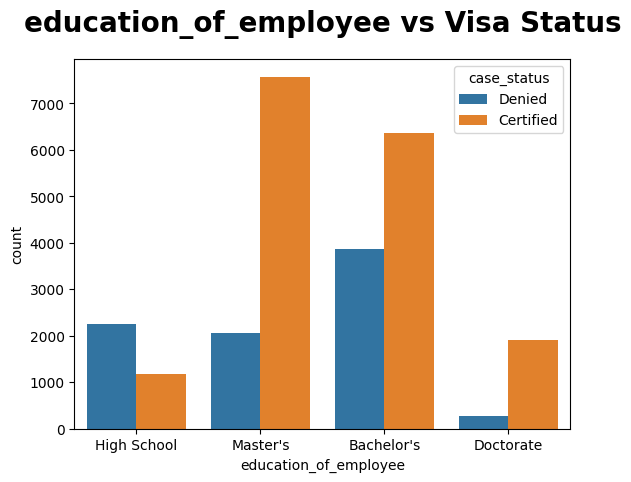

In [33]:
sns.countplot(x='education_of_employee',data=df,hue='case_status')
plt.title("education_of_employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.show()

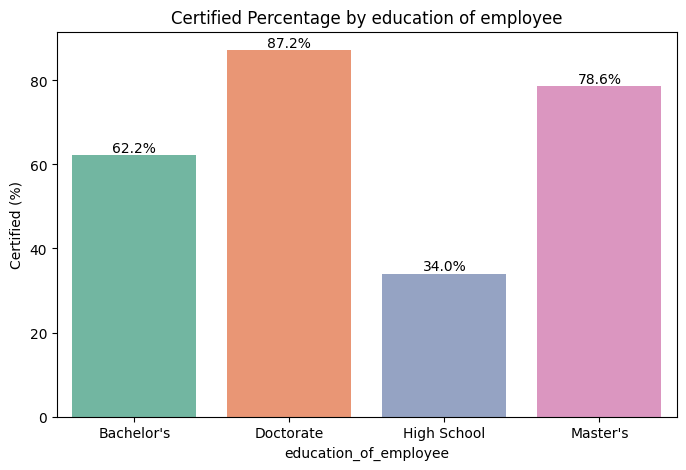

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('education_of_employee')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='education_of_employee',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by education of employee')
plt.show()

**Insights**
- education status has high impact
- `Doctorate` and `Master's` graduates have higher cange of being accepted then the others.

### 4.4 Does applicant's previous work experience has any impact on Visa status ?

In [35]:
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

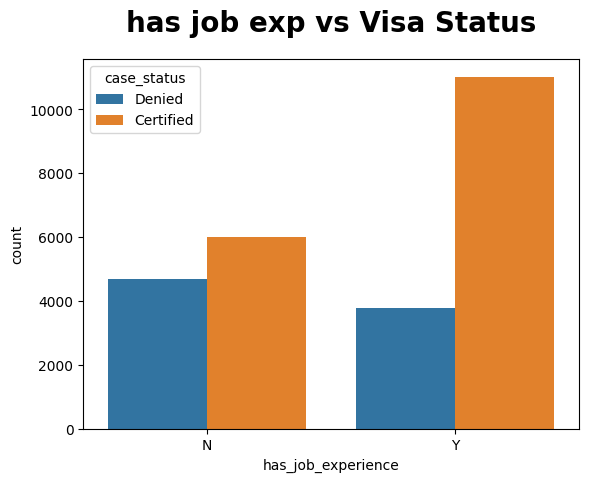

In [36]:
#plot has job exp Vs visa status
sns.countplot(x='has_job_experience',data=df,hue='case_status')
plt.title("has job exp vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.show()

certified percentage VS has job experince

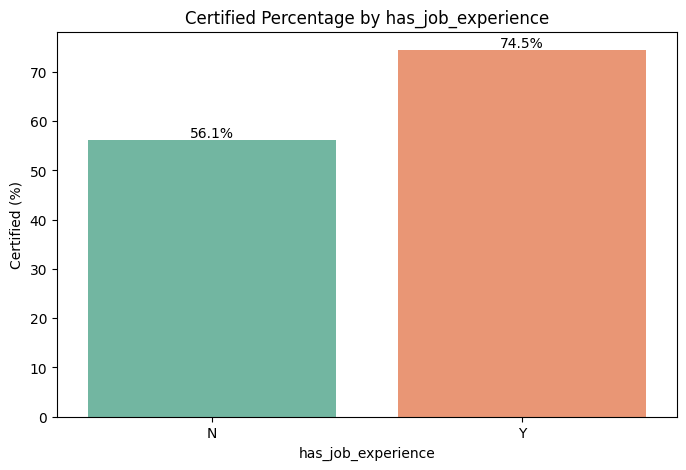

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('has_job_experience')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='has_job_experience',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by has_job_experience')
plt.show()

**Report**
* People with previous work experience has been certified 74.5% only 25.5% applicant has been denied.
* People with No previous work experience has been certified 56% and denied 43%.
* This means work experience has effect on Visa status.
* There is a slight edge for the people with work experiences then the fresheres as expected. But the difference is not huge.

### 4.5 If the Employee requires job training, does it make any impact on visa status?

In [38]:
#group by requires job trainging
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

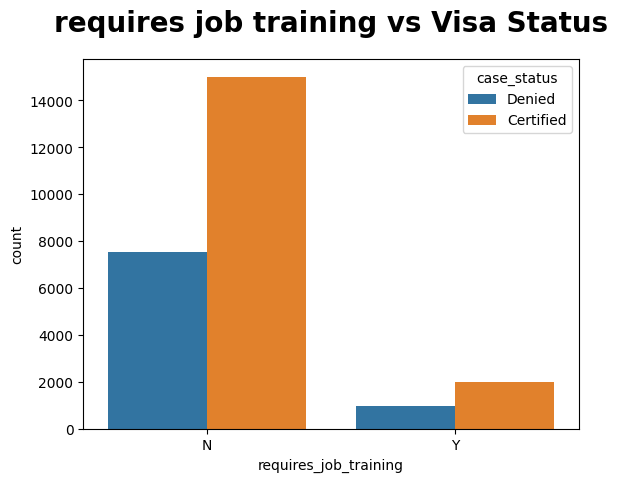

In [39]:
#plot requires job training Vs visa status
sns.countplot(x='requires_job_training',data=df,hue='case_status')
plt.title("requires job training vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.show()

certified percentage VS requires job traing

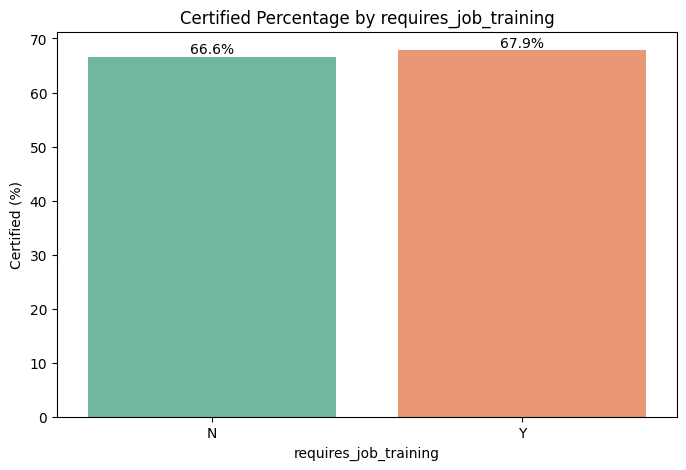

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('requires_job_training')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='requires_job_training',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by requires_job_training')
plt.show()

**Report**
* If employee requires job training and it doesn't have any effect on Visa status.
* 88% of applicant don't require job training. 
* 63% of people who doesnt want job training got certified.
* For employees who require job training 67% of people get certified.
* As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

### 4.6 Does Number of employees of employer has any impact on Visa status?

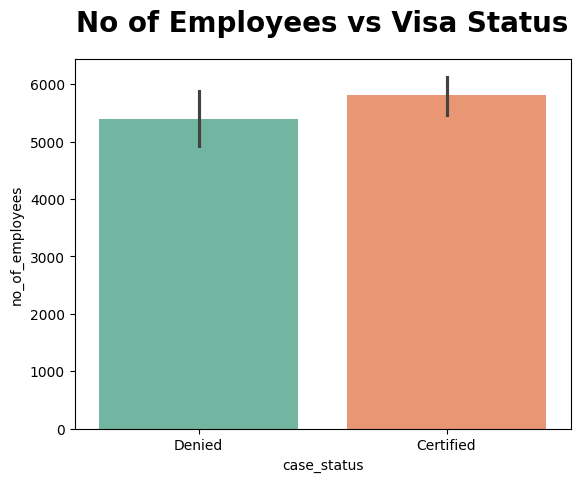

In [41]:
sns.barplot(x='case_status',y='no_of_employees',data=df,palette='Set2')
plt.title("No of Employees vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.show()

### 4.7 Wages and its impact on Visa status

In [42]:
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
unit_of_wage case_status            
Hour         Denied        65.368567
             Certified     34.631433
Month        Certified     61.797753
             Denied        38.202247
Week         Certified     62.132353
             Denied        37.867647
Year         Certified     69.885027
             Denied        30.114973

plot unit of eage vs case status

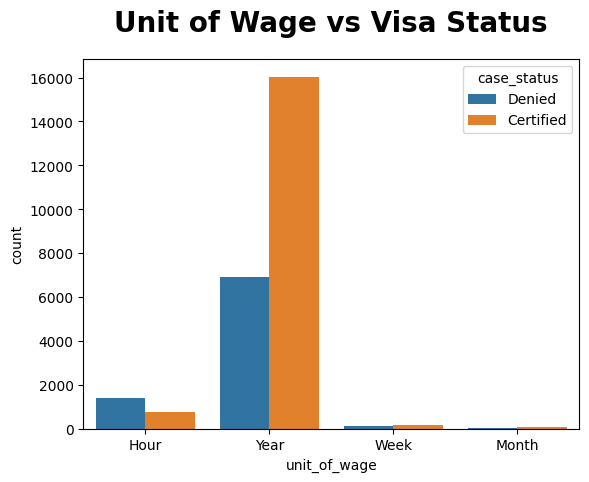

In [43]:
sns.countplot(x='unit_of_wage',data=df,hue='case_status')
plt.title("Unit of Wage vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.show()

certified percentage VS unit of wage

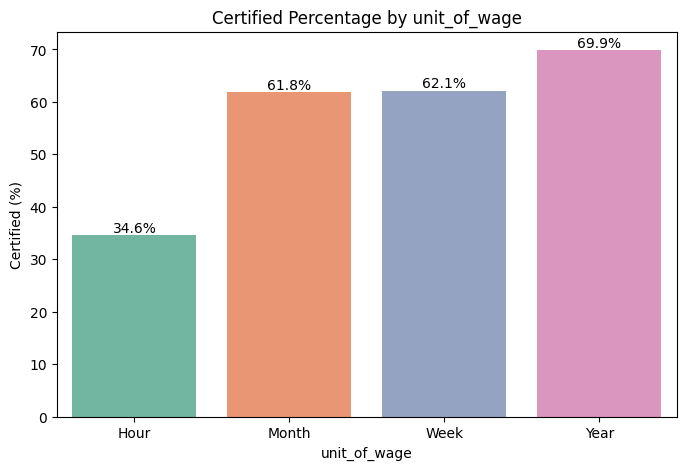

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('unit_of_wage')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='unit_of_wage',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by unit_of_wage')
plt.show()

**Report**
* For employees who applied for hourly pay 65% of them were denied.
* Yearly unit wage application were accepted for 69% and denied for 31% of the time.
* There is a higher chance of yearly contract than other and immediately followed by week and month.

### 4.7 Does Region of employment has impact on Visa status ?

In [45]:
df.groupby('region_of_employment')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
region_of_employment case_status            
Island               Certified     60.266667
                     Denied        39.733333
Midwest              Certified     75.528210
                     Denied        24.471790
Northeast            Certified     62.904795
                     Denied        37.095205
South                Certified     70.015676
                     Denied        29.984324
West                 Certified     62.253265
                     Denied        37.746735

plot region of emp Vs case status

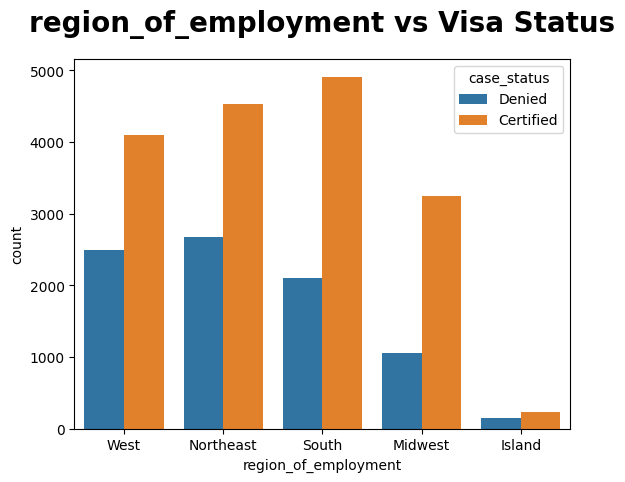

In [46]:
sns.countplot(x='region_of_employment',data=df,hue='case_status')
plt.title("region_of_employment vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.show()

certified percentage Vs region of empl

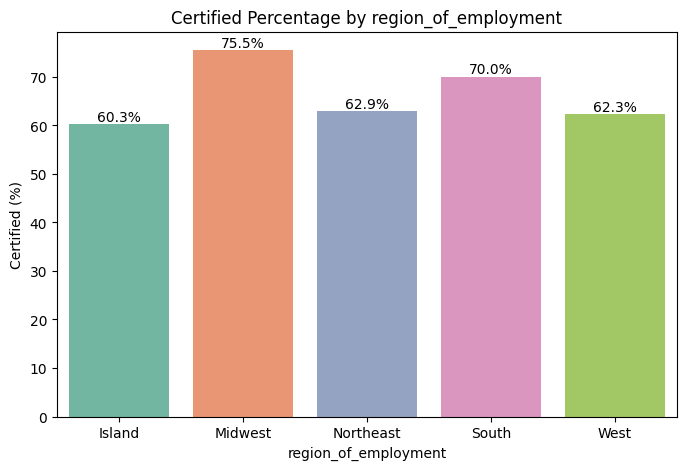

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
df_perc = (
    df.groupby('region_of_employment')['case_status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('proportion')
      .reset_index()
)

# Keep only Certified
df_cert = df_perc[df_perc['case_status'] == 'Certified']

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_cert,
    x='region_of_employment',
    y='proportion',
    palette='Set2'
)

# Add percentage labels on all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Certified (%)')
plt.title('Certified Percentage by region_of_employment')
plt.show()

**Report** 
* As per chart all the region have very similar pattern of getting Visa certified and Denied.
* There is a slight edge for `midwest` followed by `South` region

### 4.8 Does Prevailing wage has any impact on Visa status ?

In [48]:
df.groupby('prevailing_wage')['case_status'].value_counts(normalize=True).to_frame()*100

,,proportion
prevailing_wage,case_status,
2.1367,Certified,100.0
2.9561,Denied,100.0
3.0031,Denied,100.0
3.3188,Denied,100.0
3.4889,Certified,100.0
...,...,...
311734.4900,Certified,100.0
314156.0600,Certified,100.0
315497.6000,Certified,100.0


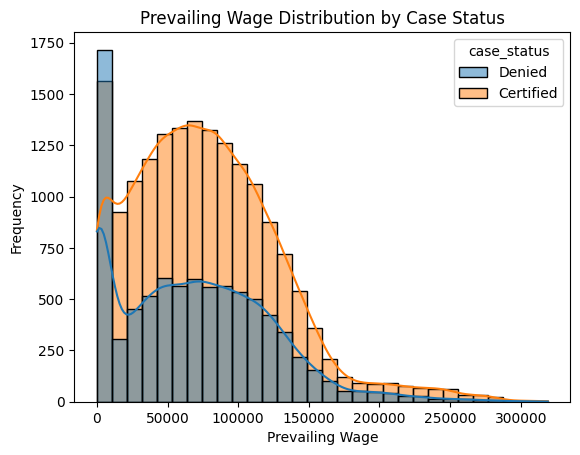

In [49]:
sns.histplot(data=df, x='prevailing_wage',hue='case_status', bins=30, kde=True)
plt.title('Prevailing Wage Distribution by Case Status')
plt.xlabel('Prevailing Wage')
plt.ylabel('Frequency')
plt.show()

#### 4.8.1 Prevailing wage based on Education

In [50]:
df.groupby('education_of_employee')['prevailing_wage'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee prevailing_wage            
Bachelor's            100.66             0.019543
                      6036.67            0.019543
                      82560.28           0.019543
                      87751.88           0.019543
                      88664.77           0.019543
...                                           ...
Master's              306021.96          0.010380
                      306206.67          0.010380
                      307716.10          0.010380
                      315497.60          0.010380
                      318446.05          0.010380

[25472 rows x 1 columns]

plot prevailing wage vs education

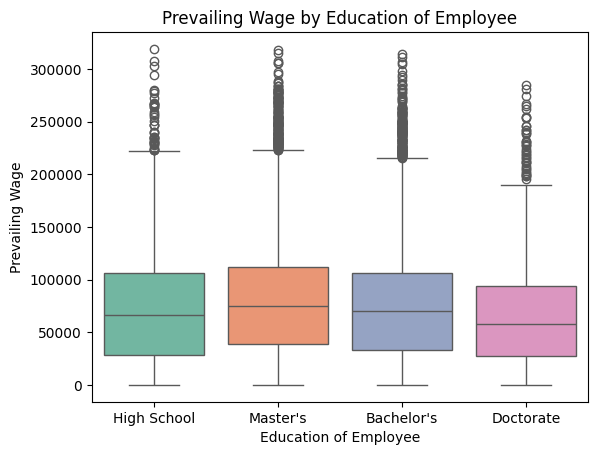

In [51]:
sns.boxplot(x='education_of_employee', y='prevailing_wage', data=df, palette='Set2')
plt.title('Prevailing Wage by Education of Employee')
plt.xlabel('Education of Employee')
plt.ylabel('Prevailing Wage')
plt.show()

In [52]:
**Report**
* Based on the above table and charts its seen that applicant with Master's education has higher average prevailing wages.
* Master's education applicants have median salary of $78.8k, which approximately 20% higher than Doctrate's average wage, which is strange.

SyntaxError: unterminated string literal (detected at line 2) (2985401435.py, line 2)

#### 4.8.2 Prevailing wage based on Job experience

In [ ]:
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame()*100


,prevailing_wage
has_job_experience,
N,7260229.0
Y,6903366.5


In [ ]:
#### 4.8.3 Prevailing wage based on Continent

In [ ]:

df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


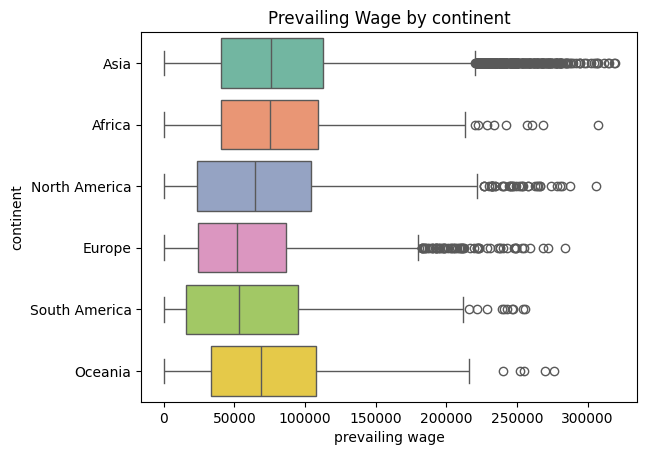

In [ ]:
sns.boxplot(x='prevailing_wage', y='continent', data=df, palette='Set2')
plt.title('Prevailing Wage by continent')
plt.xlabel('prevailing wage')
plt.ylabel('continent')
plt.show()

In [ ]:
**Report**
* Average salary of people from Asia is higher than other continents.

### 4.9 Year of Establishment vs prevailing wage


In [54]:
df.groupby('yr_of_estab')['prevailing_wage'].value_counts(normalize=True).to_frame()*100

proportion
yr_of_estab prevailing_wage            
1800        43420.11           6.250000
            62487.14           6.250000
            68613.70           6.250000
            73067.58           6.250000
            73305.46           6.250000
...                                 ...
2016        117973.61          4.347826
            122117.14          4.347826
            125088.46          4.347826
            146921.84          4.347826
            172687.53          4.347826

[25480 rows x 1 columns]

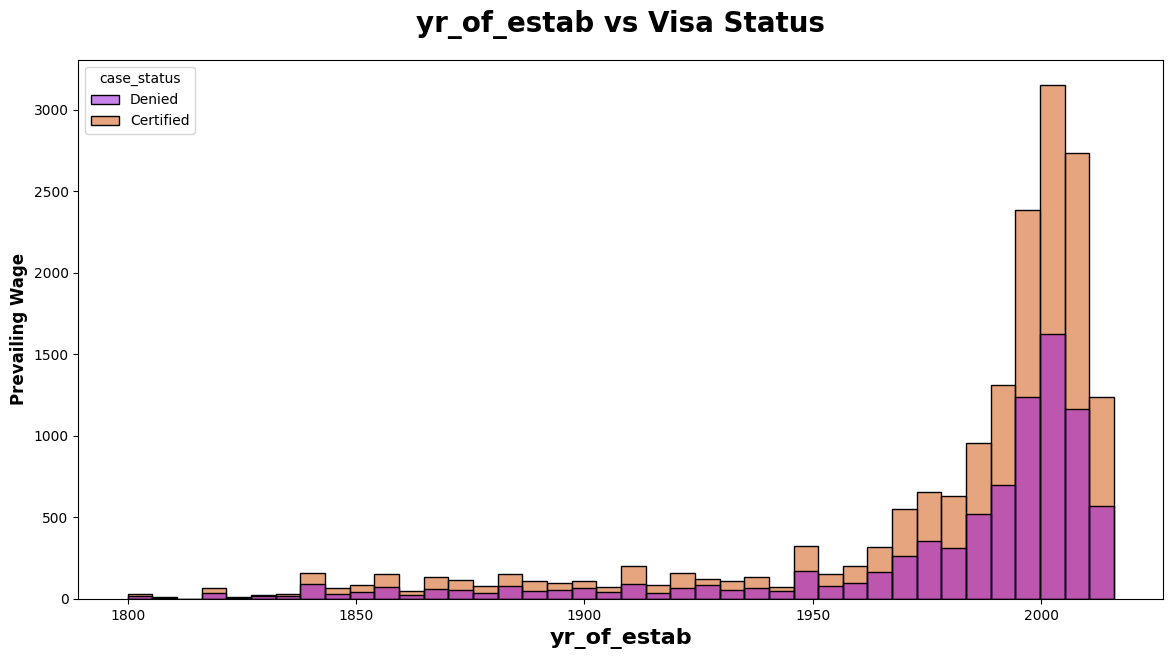

In [ ]:
plt.subplots(figsize=(14,7))
sns.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()

**Report**
* Each bins consists of 5 years.
* Many companies were established after year 2000.
* The most company establishment happened in year 2000-2005.

In [ ]:
### Final Report 
* `case_id` column can be dropped as it is an ID.
* `requires_job_training` column can be dropped as it doesn't have much impact on target variable, Proved in visualization and chi2 test.
* `no_of_employees`, `prevailing_wage` columns have outllier which should be handled.
* `continent` columns has few unique values with very less count, which can be made as **others**
* Target column `case_status` is imbalanced can be handled before model building.

In [55]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
